# Common Libraries

In [1]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
from scipy.interpolate import interp1d

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Params

In [2]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/scaled_model_cvt3_mocap.xml"
qpos_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/IK_files/trial1_IK_qpos.csv"

simulation_time_interval = 0.0001

# Initialize model

In [5]:
n_sim_perSecond = 1 / simulation_time_interval
model = mujoco.MjModel.from_xml_path(model_path)
model.opt.timestep = simulation_time_interval
joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]

# Load data

In [6]:
qpos_data = pd.read_csv(qpos_path, index_col = [0])
qpos_times = qpos_data["times"]

qvel_data = qpos_data[joint_names].diff(1) / qpos_data["times"].diff(1).iloc[1]
qvel_data = qvel_data.fillna(0)
qvel_data.insert(0, "times", qpos_times)

qacc_data = qvel_data[joint_names].diff(1) / qpos_data["times"].diff(1).iloc[1]
qacc_data = qacc_data.fillna(0)
qacc_data.insert(0, "times", qpos_times)

In [7]:
def downsampling(df, simulation_time_interval):
    df = df.copy()
    x = df["times"].values
    y = df.drop(columns = ["times"]).values
    
    new_times = np.arange(x.min(), x.max() + 1e-7, simulation_time_interval)
    f = interp1d(x, y, kind = "cubic", axis = 0, fill_value = "extrapolate")
    new_y = f(new_times)
    new_df = pd.DataFrame(new_y, columns = df.columns.drop("times"))
    new_df.insert(0, "times", new_times)
    return new_df
    
qpos_data = downsampling(qpos_data, simulation_time_interval)
qvel_data = downsampling(qvel_data, simulation_time_interval)
qacc_data = downsampling(qacc_data, simulation_time_interval)

# Constants

In [8]:
# Model constants
n_joint = len(joint_names)

# Joint indexing
interest_joint_names = joint_names
interest_joint_map = {}
for joint_name in interest_joint_names:
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]
    
    interest_joint_map[joint_name] = {
        "joint_id" : jnt_id,
        "qposadr" : qpos_idx,
        "dofadr" : dof_idx,
    }

# Set initial pose

In [9]:
# Initialize pose
mj_data = mujoco.MjData(model)
mj_data.qpos = qpos_data.iloc[0][joint_names].values
mujoco.mj_forward(model, mj_data)

# Renderer

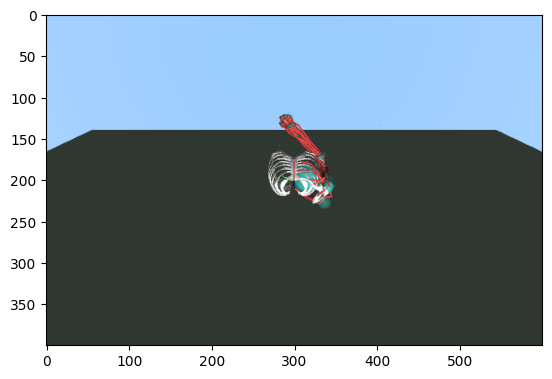

In [10]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

In [12]:
def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = mujoco.MjData(model)
    data_copy.qpos = data.qpos.copy()
    data_copy.qvel = data.qvel.copy()
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    #model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    #model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy.qfrc_inverse

# Simulation

In [26]:
# Simulation params
kp = 100.0 # Stiffness
kv = 50 # Damping
is_compensate_gravity = False

# Simulation constants
maximum_exp_time = qpos_data["times"].max()
n_simulations = int(np.round(maximum_exp_time / simulation_time_interval, 1))

interest_joint_ids = [interest_joint_map[name]["joint_id"] for name in interest_joint_names]
interest_joint_ids = np.array(interest_joint_ids)

# Initialize start pose
mj_data = mujoco.MjData(model)
mj_data.qpos = qpos_data.iloc[0][joint_names].values
mujoco.mj_forward(model, mj_data)

# Pixel
pixels = np.zeros((n_simulations, renderer.height, renderer.width, 3), dtype = np.uint8)

# Joint history
simulation_qpos = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qpos.columns = ["times"] + joint_names

simulation_qvel = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qvel.columns = ["times"] + joint_names

# Force history
simulation_qforces = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qforces.columns = ["times"] + joint_names

# Error history
simulation_qpos_errors = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qpos_errors.columns = ["times"] + joint_names

simulation_qvel_errors = pd.DataFrame(np.zeros((n_simulations, n_joint + 1)))
simulation_qvel_errors.columns = ["times"] + joint_names

# Simulation
for simulation_i in tqdm(range(n_simulations)):
    simulation_time = simulation_i * simulation_time_interval
    
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()

    # Goal
    goal_i = np.searchsorted(qpos_times, simulation_time)
    goal_qpos = qpos_data.iloc[goal_i][interest_joint_names].values
    goal_qvel = qvel_data.iloc[goal_i][interest_joint_names].values
    
    # Calculate error between current and goal joint angle
    error_q = np.zeros_like(goal_qpos)
    error_q[interest_joint_ids] = goal_qpos - current_qpos[interest_joint_ids]

    error_v = np.zeros_like(goal_qvel)
    error_v[interest_joint_ids] = 0 - current_qvel[interest_joint_ids]
    
    # Force1
    qforces1 = kp * error_q + kv * error_v
    if is_compensate_gravity:
        qforces1 += mj_data.qfrc_bias
    
    # Force2
    qforces2 = get_qfrc(model, mj_data, goal_qpos)

    # Apply force
    qforces = qforces1
    mj_data.qfrc_applied[:] = qforces
    
    # Record joints history
    simulation_qpos.iloc[simulation_i] = np.hstack([simulation_time, current_qpos])
    simulation_qvel.iloc[simulation_i] = np.hstack([simulation_time, current_qvel])

    # Record forces
    simulation_qforces.iloc[simulation_i] = np.hstack([simulation_time, qforces])
    
    # Record Errors
    simulation_qpos_errors.iloc[simulation_i] = np.hstack([simulation_time, error_q])
    simulation_qvel_errors.iloc[simulation_i] = np.hstack([simulation_time, error_v])
    
    # Forward dyanmics
    mujoco.mj_step(model, mj_data)   
    
    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[simulation_i] = renderer.render()

  5%|▌         | 680/13332 [00:04<01:15, 167.74it/s]


KeyboardInterrupt: 

In [25]:
mediapy.show_video(pixels, fps = 30)

RuntimeError: Error writing '/tmp/tmprwffx117/file.mp4': 

# QPos plot

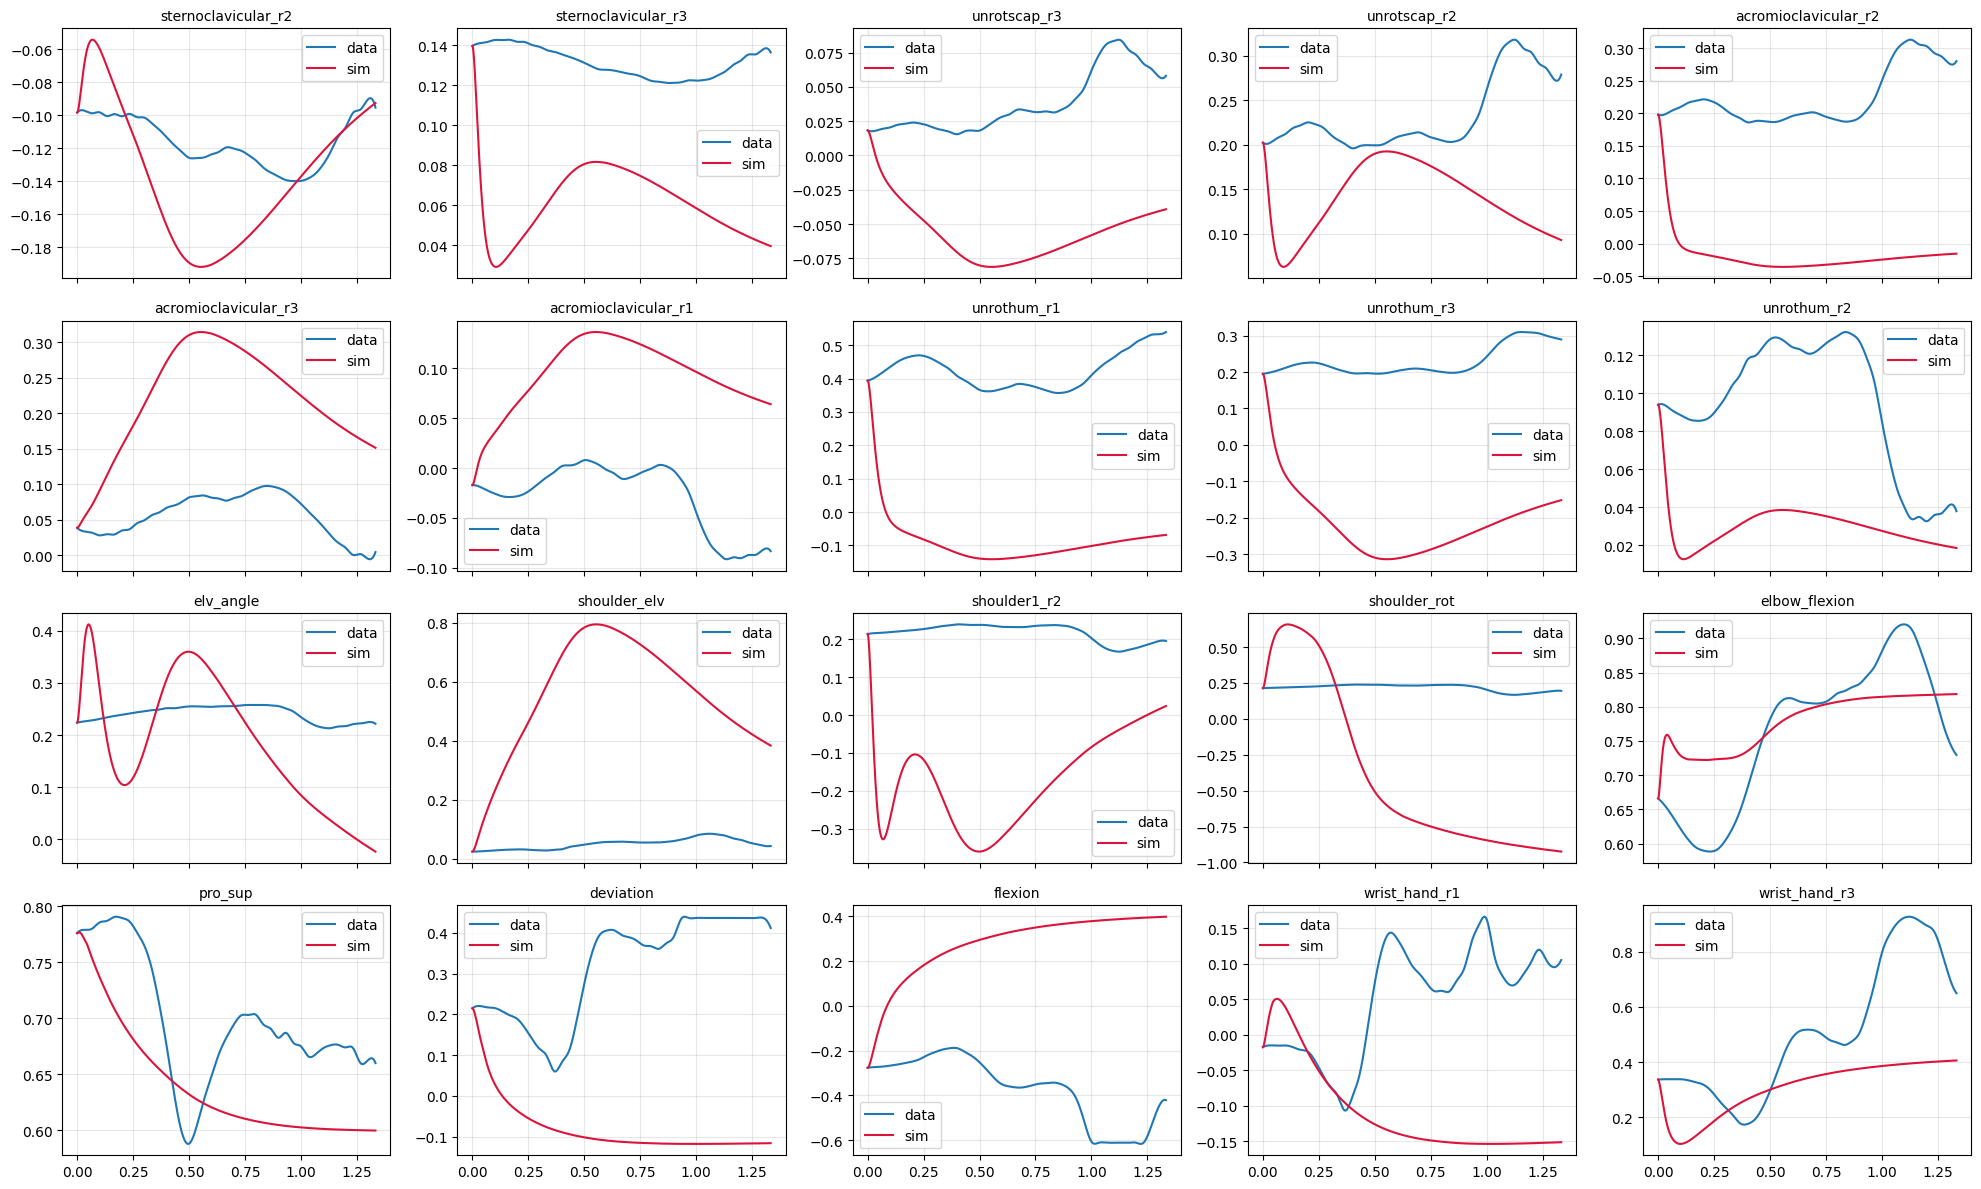

In [22]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(qpos_data["times"], qpos_data[joint_name], label = "data")
    ax.plot(simulation_qpos["times"], simulation_qpos[joint_name], color='crimson', lw=1.5, label = "sim")
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend()
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Error plot

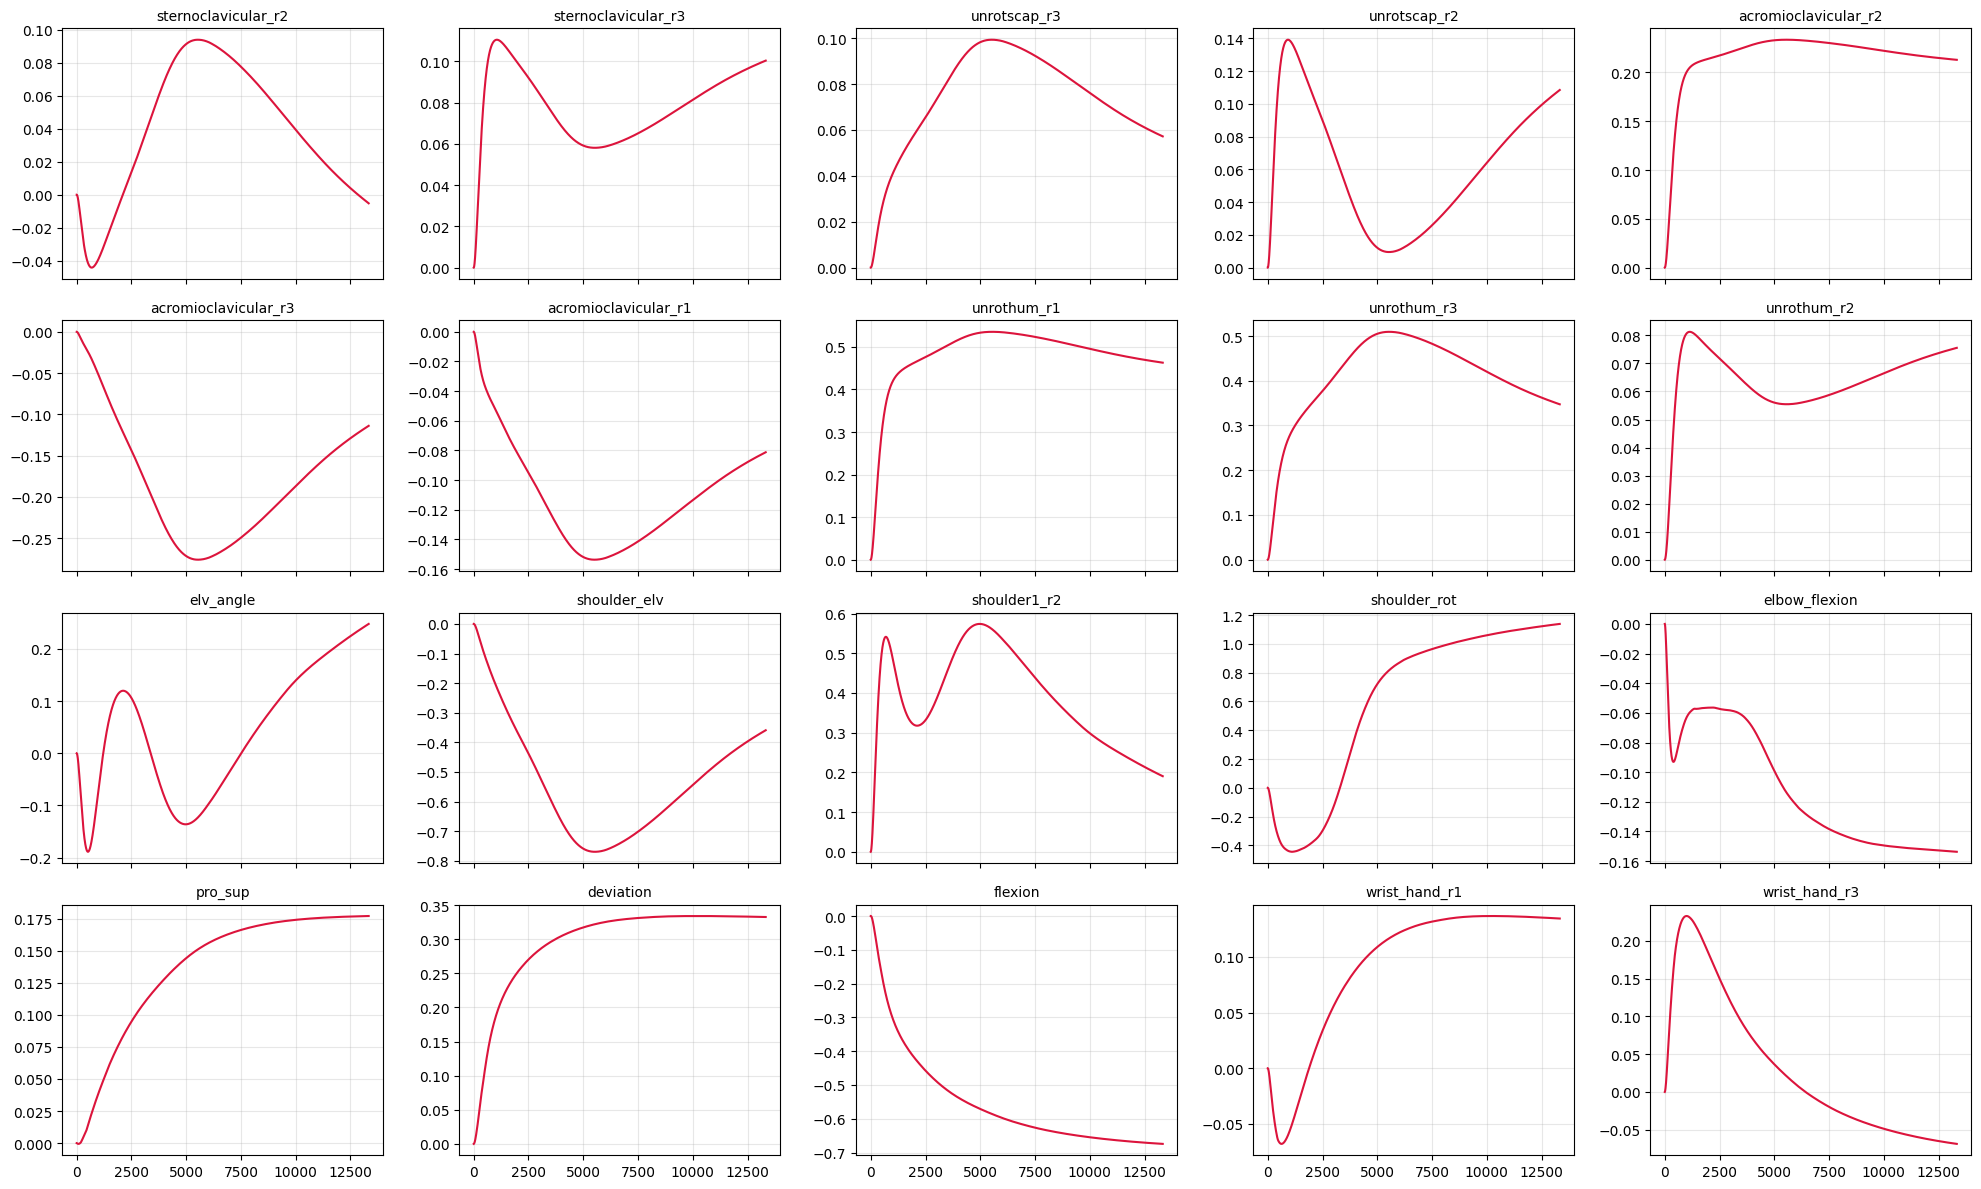

In [23]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(simulation_qpos_errors[joint_name], color='crimson', lw=1.5)
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Force plot

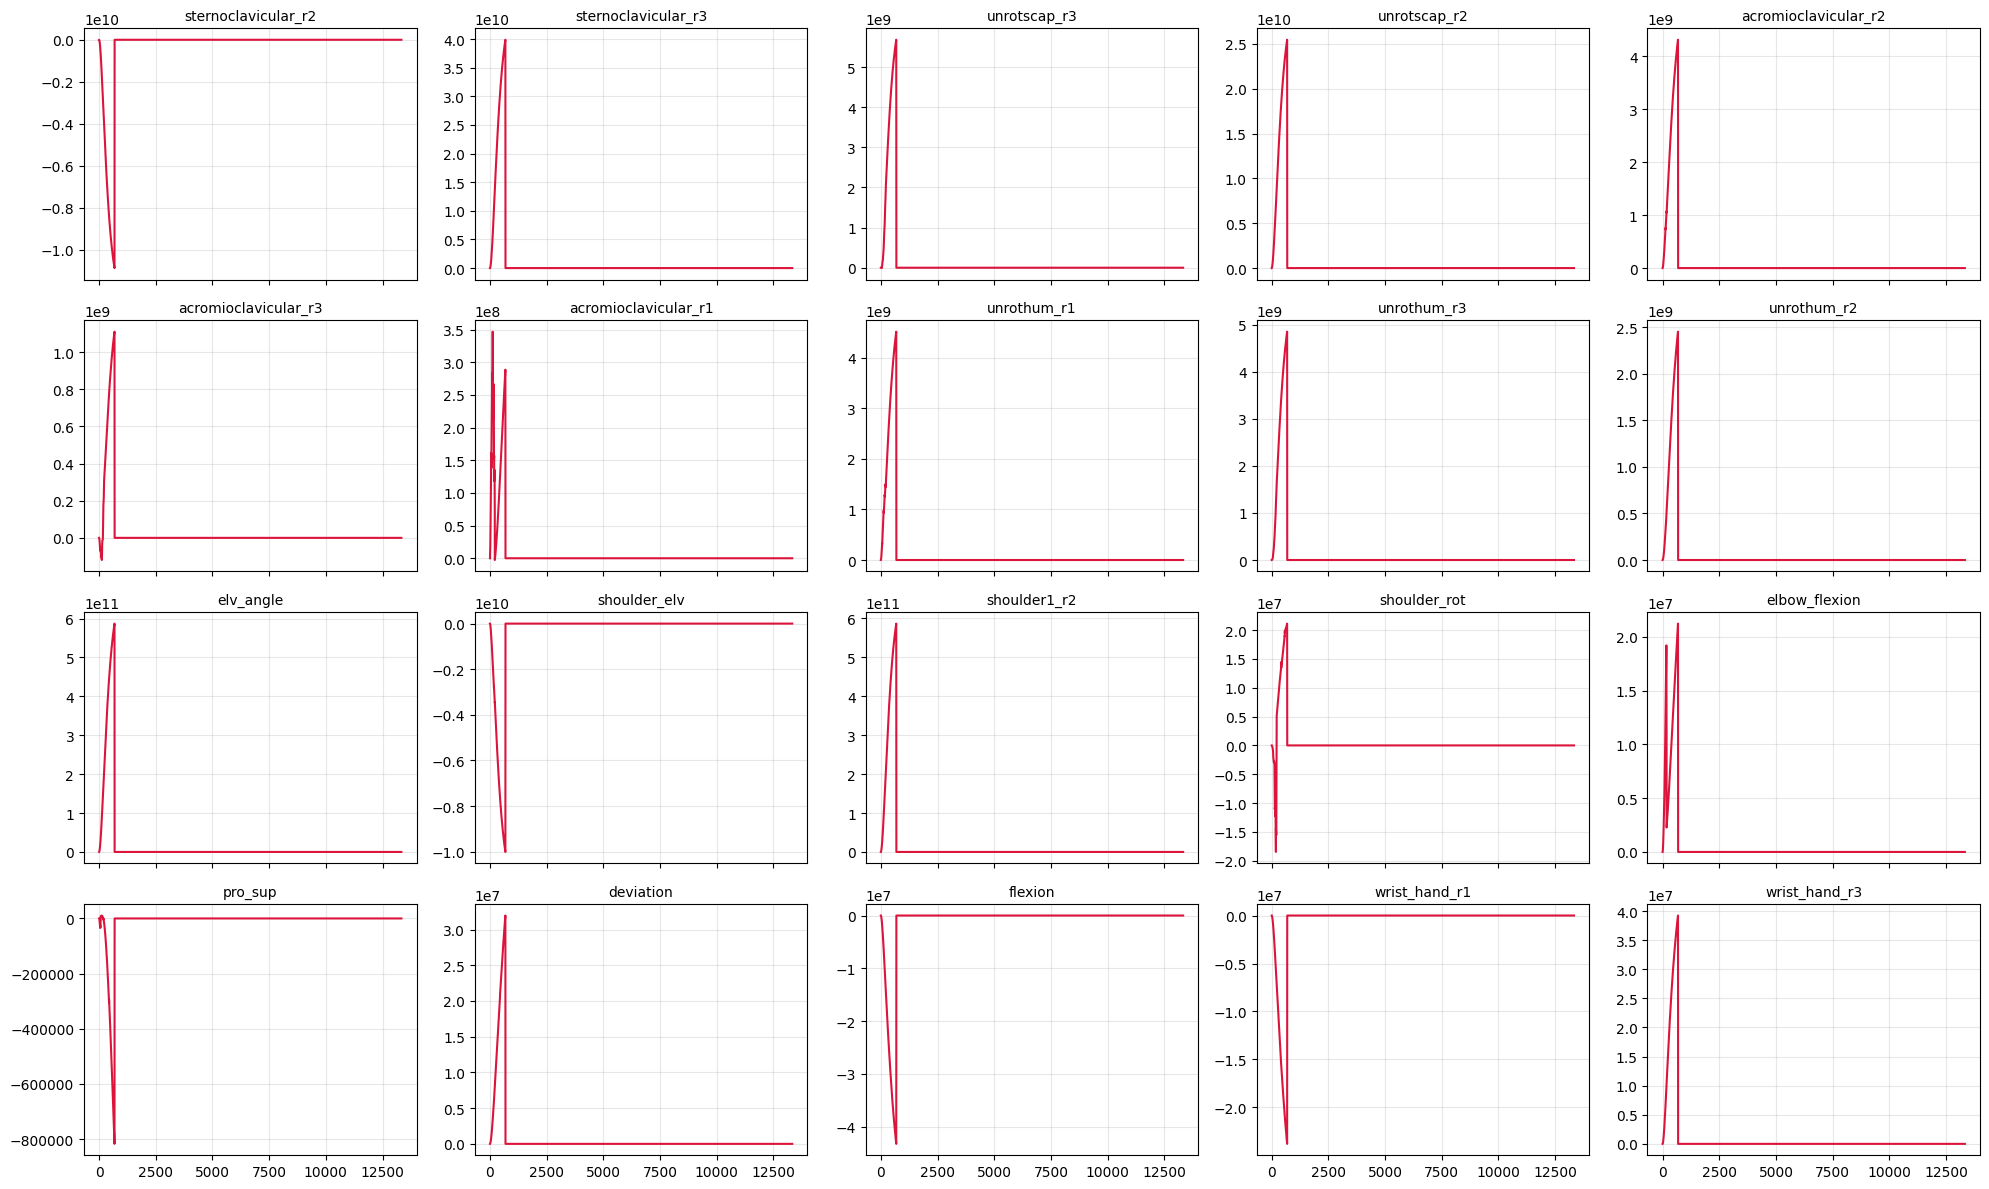

In [27]:
# Plot parameters
n_cols = 5
n_rows = (len(interest_joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(interest_joint_names):
    ax = axes[i]
    ax.plot(simulation_qforces[joint_name], color = "crimson", lw=1.5)
    ax.set_title(joint_name, fontsize=10)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()